In [2]:
import zipfile

def look_at_zip(zip_path):
    with zipfile.ZipFile(zip_path,"r") as z:
        return z.namelist()

look_at_zip("../data/FracFocusCSV.zip")

['DisclosureList_1.csv',
 'FracFocusRegistry_1.csv',
 'FracFocusRegistry_10.csv',
 'FracFocusRegistry_11.csv',
 'FracFocusRegistry_12.csv',
 'FracFocusRegistry_13.csv',
 'FracFocusRegistry_14.csv',
 'FracFocusRegistry_15.csv',
 'FracFocusRegistry_2.csv',
 'FracFocusRegistry_3.csv',
 'FracFocusRegistry_4.csv',
 'FracFocusRegistry_5.csv',
 'FracFocusRegistry_6.csv',
 'FracFocusRegistry_7.csv',
 'FracFocusRegistry_8.csv',
 'FracFocusRegistry_9.csv',
 'readme csv.txt',
 'WaterSource_1.csv']

In [3]:
def read_file_from_zip(zip_path, file_name):
    with zipfile.ZipFile(zip_path,"r") as z:
        contents = z.read(file_name)
        text = contents.decode("utf-8")
        print(text)
        return 
    
read_file_from_zip("../data/FracFocusCSV.zip", "readme csv.txt")

FRACFOCUS DATA DICTIONARY - Last updated: November 2023
--------------------------------------------------------
This data dictionary defines the columns for files in the FracFocus CSV download. This download includes all availalbe Data that can be found by searching at: https://fracfocus.org/wells


File Name: DisclosureList_#.csv
--------------------------
DisclosureId - Key index for the Disclosure data.

JobStartDate - The date on which the hydraulic fracturing job was initiated.  Does not include site preparation or setup.

JobEndDate - The date on which the hydraulic fracturing job was completed.  Does not include site teardown.

APINumber - The American Petroleum Institute well identification number formatted as follows xx-xxx-xxxxx-00-00 Where: First two digits 
represent the state, second three digits represent the county, third 5 digits represent the well.

StateName - The name of the state where the surface location of the well resides.  Calculated from the API number.

Coun

In [4]:
def zip_extract(zip_path):
    with zipfile.ZipFile(zip_path,"r") as z:
        z.extractall("../data/raw/")

zip_extract("../data/FracFocusCSV.zip")

In [5]:
import pandas as pd
def read_disclosure_list(raw_data):
    df = pd.read_csv(raw_data)
    print(df.shape)
    print(df.columns)
    print(df.head())
    print(df.dtypes)

read_disclosure_list("../data/raw/DisclosureList_1.csv")


C:\Users\gjbuc\AppData\Local\Temp\ipykernel_6292\3417680491.py:3: DtypeWarning: Columns (0: APINumber) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(raw_data)


(246323, 17)
Index(['DisclosureId', 'JobStartDate', 'JobEndDate', 'APINumber', 'StateName',
       'CountyName', 'OperatorName', 'WellName', 'Latitude', 'Longitude',
       'Projection', 'TVD', 'TotalBaseWaterVolume', 'TotalBaseNonWaterVolume',
       'FFVersion', 'FederalWell', 'IndianWell'],
      dtype='str')
                           DisclosureId            JobStartDate  \
0  02cd05a7-4b73-4722-9fba-1f798842a879    5/1/1955 12:00:00 AM   
1  416d8b17-822f-4743-8c79-baf015a6de24   5/19/1982 12:00:00 AM   
2  89f97571-945b-4473-8be8-2aca326f04ad    2/7/1995 12:00:00 AM   
3  876b362a-e057-4815-a45e-e311c5ae1c1f   6/11/1996 12:00:00 AM   
4  0902e8c7-593f-42e1-b02c-283b0edceea7  12/13/2001 12:00:00 AM   

               JobEndDate       APINumber StateName CountyName  \
0    5/1/1955 12:00:00 AM  42317372620000     Texas     Martin   
1   5/19/1982 12:00:00 AM  49009219470000   Wyoming   Converse   
2    2/7/1995 12:00:00 AM  49009228850000   Wyoming   Converse   
3   6/11/1996 12:00

In [6]:
midland_basin_counties = ["Midland", "Martin", "Howard", "Glasscock", "Upton", "Reagan"]
df = pd.read_csv("../data/raw/DisclosureList_1.csv", dtype={"APINumber": str})
mb_df = df[(df["StateName"] == "Texas") & (df["CountyName"].isin(midland_basin_counties)) & (df["FFVersion"] >= 2)]
print(mb_df.shape)
print(mb_df.head())
print(mb_df["OperatorName"].value_counts().head(20))

(29709, 17)
                               DisclosureId            JobStartDate  \
6117   1add74a9-2fb7-4400-aae1-90c24178dab9    7/7/2011 12:00:00 AM   
9673   99152a65-de6b-4cbc-b474-c33f77b8330a   9/19/2011 12:00:00 AM   
11710  b5fa2603-1b4d-47e0-8b56-c3ab944fefe1  10/31/2011 12:00:00 AM   
12518  2b32237f-e816-4f0d-9d9b-fa7a00ffe651  11/17/2011 12:00:00 AM   
13941  05e0802b-3553-4c2d-9e95-8772b2b01b40  12/16/2011 12:00:00 AM   

                   JobEndDate       APINumber StateName CountyName  \
6117     7/8/2011 12:00:00 AM  42173340000000     Texas  Glasscock   
9673    9/24/2011 12:00:00 AM  42461374570000     Texas      Upton   
11710   11/3/2011 12:00:00 AM  42173343850000     Texas  Glasscock   
12518  11/18/2011 12:00:00 AM  42317363510000     Texas     Martin   
13941  12/16/2011 12:00:00 AM  42317373120000     Texas     Martin   

                        OperatorName                   WellName   Latitude  \
6117   Royalty Land & Dev. Co., Inc.         Lois Blalock #C71

In [7]:
from pathlib import Path

midland_basin_counties = ["Midland", "Martin", "Howard", "Glasscock", "Upton", "Reagan"]
df = pd.read_csv("../data/raw/DisclosureList_1.csv", dtype={"APINumber": str})
mb_df = df[(df["StateName"] == "Texas") & (df["CountyName"].isin(midland_basin_counties)) & (df["FFVersion"] >= 2)]
mb_df.to_parquet("../data/processed/midland_basin_disclosures.parquet", index=False)

In [8]:
from pathlib import Path
parquet_path = Path("../data/processed/midland_basin_disclosures.parquet")
print(f"Exists: {parquet_path.exists()}")
print(f"Size: {parquet_path.stat().st_size / 1e6:.2f} MB")

Exists: True
Size: 2.93 MB


In [9]:
mb_df = pd.read_parquet("../data/processed/midland_basin_disclosures.parquet")

mb_df["JobStartDate"] = pd.to_datetime(mb_df["JobStartDate"])
mb_df["JobEndDate"] = pd.to_datetime(mb_df["JobEndDate"])
print(mb_df[["JobStartDate", "JobEndDate"]].dtypes)
print(mb_df[["JobStartDate", "JobEndDate"]].head())

C:\Users\gjbuc\AppData\Local\Temp\ipykernel_6292\2832643427.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  mb_df["JobStartDate"] = pd.to_datetime(mb_df["JobStartDate"])
C:\Users\gjbuc\AppData\Local\Temp\ipykernel_6292\2832643427.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  mb_df["JobEndDate"] = pd.to_datetime(mb_df["JobEndDate"])


JobStartDate    datetime64[us]
JobEndDate      datetime64[us]
dtype: object
  JobStartDate JobEndDate
0   2011-07-07 2011-07-08
1   2011-09-19 2011-09-24
2   2011-10-31 2011-11-03
3   2011-11-17 2011-11-18
4   2011-12-16 2011-12-16


In [10]:
mb_df["Year"] = mb_df["JobStartDate"].dt.year

wells_per_year = mb_df["Year"].value_counts().sort_index()
print(wells_per_year)

Year
2007.0       3
2011.0       6
2012.0     147
2013.0    2312
2014.0    3260
2015.0    1890
2016.0    1332
2017.0    1852
2018.0    2334
2019.0    2501
2020.0    1592
2021.0    2321
2022.0    2589
2023.0    2470
2024.0    2518
2025.0    2186
2026.0     394
Name: count, dtype: int64


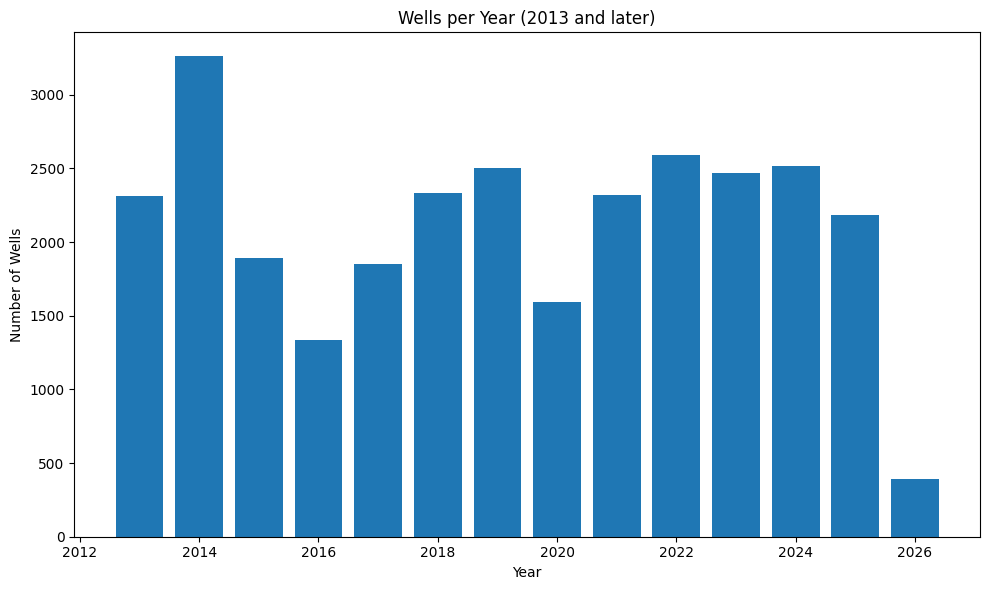

In [11]:
import matplotlib.pyplot as plt

wells_after_2013 = wells_per_year[wells_per_year.index >= 2013]
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(wells_after_2013.index, wells_after_2013.values)
ax.set_title("Wells per Year (2013 and later)")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Wells")
plt.tight_layout()
plt.show()
fig.savefig("../figures/wells_per_year.png")

In [ ]:
median_water_per_year = mb_df.groupby("Year")["TotalBaseWaterVolume"].median()
median_water_per_year = median_water_per_year[median_water_per_year.index >= 2013]
median_water_per_year_bbl = median_water_per_year / 42
print(median_water_per_year_bbl)

Year
2013.0     31832.750000
2014.0     35998.000000
2015.0    158742.595238
2016.0    320201.000000
2017.0    391584.000000
2018.0    414552.523810
2019.0    452063.738095
2020.0    457859.904762
2021.0    470827.000000
2022.0    489570.738095
2023.0    511361.428571
2024.0    524854.000000
2025.0    525197.000000
2026.0    527580.000000
Name: TotalBaseWaterVolume, dtype: float64


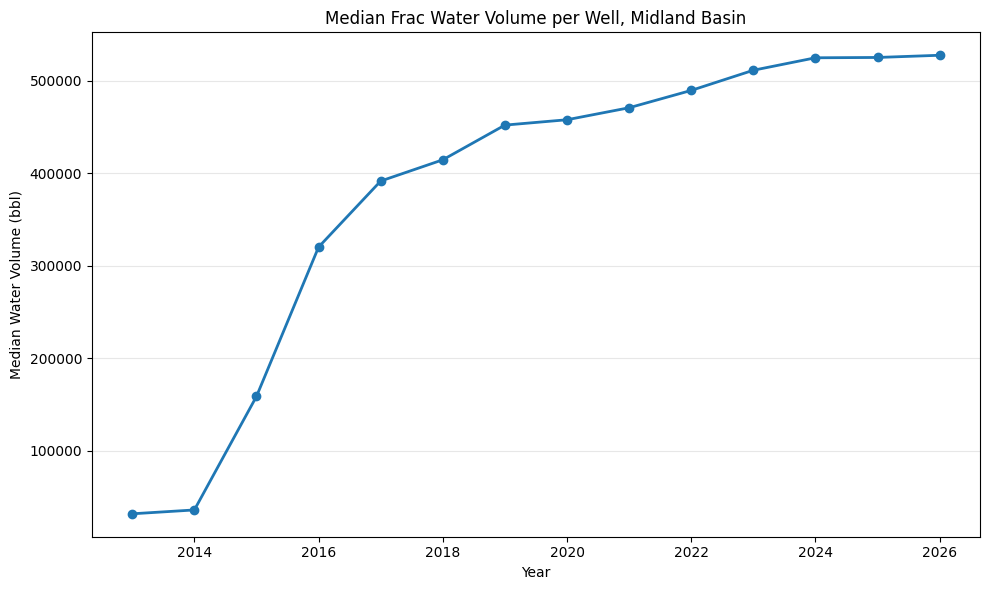

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(median_water_per_year_bbl.index,median_water_per_year_bbl.values, marker="o", linewidth=2,)
ax.set_title("Median Frac Water Volume per Well, Midland Basin")
ax.set_xlabel("Year")
ax.set_ylabel("Median Water Volume (bbl)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig("../figures/median_water_per_year.png")
plt.show()

In [21]:
median_water_with_well_count= mb_df.groupby("Year")["TotalBaseWaterVolume"].agg(["median", "count"])
median_water_with_well_count = median_water_with_well_count[(median_water_with_well_count.index >= 2013) & (median_water_with_well_count.index <= 2025)]
median_water_with_well_count["median"] = median_water_with_well_count["median"] / 42
print(median_water_with_well_count)

               median  count
Year                        
2013.0   31832.750000   2312
2014.0   35998.000000   3260
2015.0  158742.595238   1890
2016.0  320201.000000   1332
2017.0  391584.000000   1851
2018.0  414552.523810   2334
2019.0  452063.738095   2501
2020.0  457859.904762   1592
2021.0  470827.000000   2321
2022.0  489570.738095   2589
2023.0  511361.428571   2470
2024.0  524854.000000   2518
2025.0  525197.000000   2186


KeyError: 'Year'

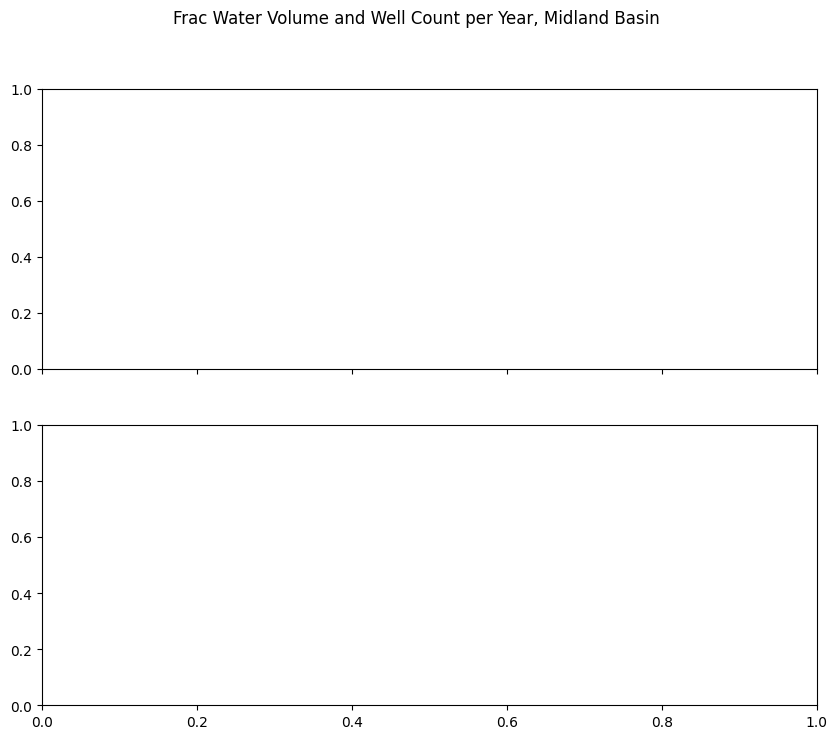

In [28]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.suptitle("Frac Water Volume and Well Count per Year, Midland Basin")
ax1.bar(median_water_per_year_bbl["Year"], median_water_per_year_bbl["median"])
ax1.set_ylabel("Number of Wells")
ax2.plot(median_water_per_year_bbl["count"].index, median_water_per_year_bbl["count"].values, marker="o", linewidth=2,)
ax2.set_xlabel("Year")
ax2.set_ylabel("Median Water Volume (bbl)")
fig.savefig("../figures/activity_and_intensity.png.png")
plt.tight_layout()
plt.show()